In [13]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

In [14]:
tickers = ["HDFCBANK.NS", "KOTAKBANK.NS"]

df = yf.download(
    tickers,
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=False,
    multi_level_index=False
)['Adj Close']

df.columns = ['hdfcbank', 'kotakbank']
df.dropna(inplace=True)

[*********************100%***********************]  2 of 2 completed


In [15]:
import statsmodels.api as sm

X = df['kotakbank']
y = df['hdfcbank']

model = sm.OLS(y, X).fit()
beta = model.params[0]

df['spread'] = df['hdfcbank'] - beta * df['kotakbank']

In [16]:
from statsmodels.tsa.stattools import adfuller

adf = adfuller(df['spread'], maxlag=1)

t_stat = adf[0]
critical = adf[4]['5%']

print("ADF OK:", t_stat < critical)

ADF OK: True


In [17]:
spread = df['spread'].dropna()

spread_lag = spread.shift(1)
spread_ret = spread - spread_lag

data = pd.concat([spread_lag, spread_ret], axis=1).dropna()

model_hl = sm.OLS(data.iloc[:,1], sm.add_constant(data.iloc[:,0])).fit()
beta_hl = model_hl.params[1]

half_life = -np.log(2) / beta_hl
print("Half-life:", half_life)

Half-life: 49.82668143107295


In [18]:
window = 90
p_vals = []

for i in range(window, len(spread)):
    sample = spread[i-window:i]
    p_vals.append(adfuller(sample)[1])

df['adf_p'] = [None]*window + p_vals

In [19]:
mean = spread.rolling(window).mean()
std = spread.rolling(window).std()

df['z'] = (spread - mean) / std

In [20]:
df['long'] = df['z'] < -2
df['short'] = df['z'] > 2
df['exit'] = df['z'].abs() < 0.5

df['tradable'] = df['adf_p'] < 0.05

In [21]:
position = 0
positions = []

for i in range(len(df)):
    if df['tradable'].iloc[i]:
        if df['long'].iloc[i]:
            position = 1
        elif df['short'].iloc[i]:
            position = -1
        elif df['exit'].iloc[i]:
            position = 0
    else:
        position = 0
    positions.append(position)

df['position'] = pd.Series(positions, index=df.index)
df['position'] = df['position'].shift(1).fillna(0)

In [22]:
df['spread_ret'] = df['spread'].diff()
df['pnl'] = df['position'] * df['spread_ret']
df['cum_pnl'] = df['pnl'].cumsum()

In [23]:
df['trade_change'] = df['position'].diff().fillna(0)

trades = df[df['trade_change'] != 0]
total_trades = len(trades) // 2

trade_pnls = []
entry = None

for i in range(len(df)):
    if df['trade_change'].iloc[i] != 0:
        if entry is None:
            entry = df['cum_pnl'].iloc[i]
        else:
            exit_pnl = df['cum_pnl'].iloc[i]
            trade_pnls.append(exit_pnl - entry)
            entry = None

profitable_trades = sum(1 for t in trade_pnls if t > 0)

daily_ret = df['pnl']

sharpe = np.sqrt(252) * daily_ret.mean() / daily_ret.std()

downside = daily_ret[daily_ret < 0]
sortino = np.sqrt(252) * daily_ret.mean() / downside.std()

max_dd = (df['cum_pnl'] - df['cum_pnl'].cummax()).min()

print("Total trades:", total_trades)
print("Profitable trades:", profitable_trades)
print("Sharpe:", sharpe)
print("Sortino:", sortino)
print("Max Drawdown:", max_dd)

Total trades: 6
Profitable trades: 0
Sharpe: 0.3037058732859322
Sortino: 0.0630486116511149
Max Drawdown: -15.151044326276974


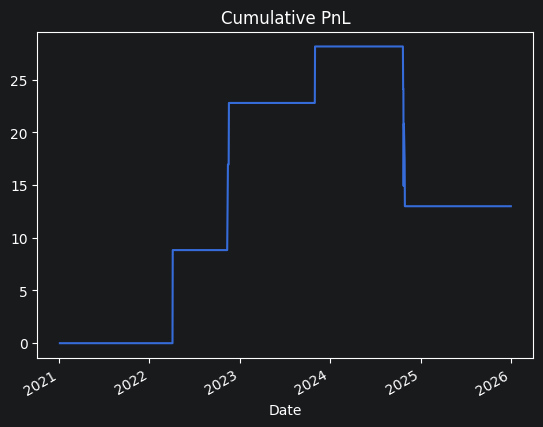

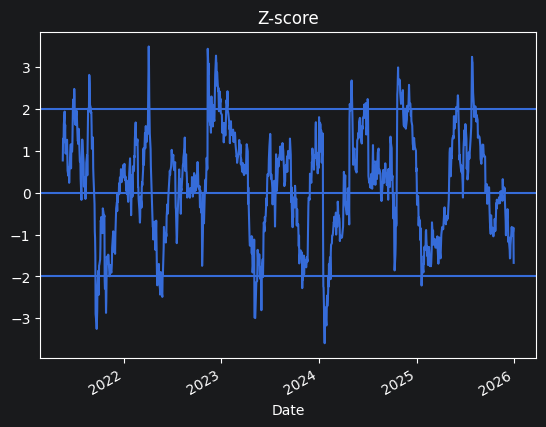

In [24]:
import matplotlib.pyplot as plt

plt.figure()
df['cum_pnl'].plot(title="Cumulative PnL")
plt.show()

plt.figure()
df['z'].plot(title="Z-score")
plt.axhline(2)
plt.axhline(-2)
plt.axhline(0)
plt.show()